In [1]:
!pip install wfdb tensorflow numpy matplotlib scikit-learn


In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import json

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense,
    RepeatVector, TimeDistributed
)


In [3]:
wfdb.dl_database(
    'mitdb',
    dl_dir='mitdb'
)


Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [4]:
NORMAL_RECORDS = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119'
]


In [5]:
WINDOW_SIZE = 140
HALF_WINDOW = WINDOW_SIZE // 2


In [6]:
def extract_normal_windows(record_id):
    record = wfdb.rdrecord(f'mitdb/{record_id}')
    annotation = wfdb.rdann(f'mitdb/{record_id}', 'atr')

    signal = record.p_signal[:,0]   # MLII lead
    fs = record.fs

    windows = []

    for idx, symbol in zip(annotation.sample, annotation.symbol):
        if symbol == 'N':
            if idx - HALF_WINDOW >= 0 and idx + HALF_WINDOW < len(signal):
                window = signal[idx-HALF_WINDOW : idx+HALF_WINDOW]
                windows.append(window)

    return np.array(windows).reshape(-1, WINDOW_SIZE), fs

In [7]:
all_windows = []
sampling_rate = None

for rec in NORMAL_RECORDS:
    windows, fs = extract_normal_windows(rec)
    all_windows.append(windows)
    sampling_rate = fs

all_windows = np.vstack(all_windows)
print("Total normal windows:", all_windows.shape)
print("Sampling rate:", sampling_rate)

Total normal windows: (25689, 140)
Sampling rate: 360


In [8]:
scaler = MinMaxScaler(feature_range=(-1, 1))

all_windows = scaler.fit_transform(
    all_windows.reshape(-1,1)
).reshape(all_windows.shape)


In [9]:
X = all_windows.reshape((-1, WINDOW_SIZE, 1))
print("Training data shape:", X.shape)


Training data shape: (25689, 140, 1)


In [10]:
input_layer = Input(shape=(WINDOW_SIZE, 1))

encoded = LSTM(64, return_sequences=True)(input_layer)
encoded = LSTM(32)(encoded)

decoded = RepeatVector(WINDOW_SIZE)(encoded)
decoded = LSTM(32, return_sequences=True)(decoded)
decoded = LSTM(64, return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(1))(decoded)

model = Model(input_layer, decoded)
model.compile(optimizer='adam', loss='mse')

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 140, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 140, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 140, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 140, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 140, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 140, 1)         │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,529 (244.25 KB)

 Trainable params: 62,529 (244.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X, X,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    shuffle=True
)


Epoch 1/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 161s 808ms/step - loss: 0.0075 - val_loss: 0.0061
Epoch 2/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 145s 792ms/step - loss: 0.0063 - val_loss: 0.0060
Epoch 3/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 133s 733ms/step - loss: 0.0061 - val_loss: 0.0059
Epoch 4/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 140s 772ms/step - loss: 0.0060 - val_loss: 0.0061
Epoch 5/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 146s 805ms/step - loss: 0.0060 - val_loss: 0.0058
Epoch 6/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 155s 857ms/step - loss: 0.0060 - val_loss: 0.0059
Epoch 7/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 140s 773ms/step - loss: 0.0059 - val_loss: 0.0063
Epoch 8/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 144s 795ms/step - loss: 0.0060 - val_loss: 0.0058
Epoch 9/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 148s 816ms/step - loss: 0.0061 - val_loss: 0.0058
Epoch 10/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 203s 821ms/step - loss: 0.0059 - val_loss: 0.0059
Epoch 11/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 201s 816ms/step - loss: 0.0059 - val_loss: 0.0058
Epoch 12

In [12]:
X_pred = model.predict(X)

reconstruction_error = np.mean(
    np.square(X - X_pred),
    axis=(1,2)
)


803/803 ━━━━━━━━━━━━━━━━━━━━ 62s 75ms/step


In [13]:
threshold = np.mean(reconstruction_error) + 3*np.std(reconstruction_error)
print("Anomaly Threshold:", threshold)


Anomaly Threshold: 0.022212355755578863


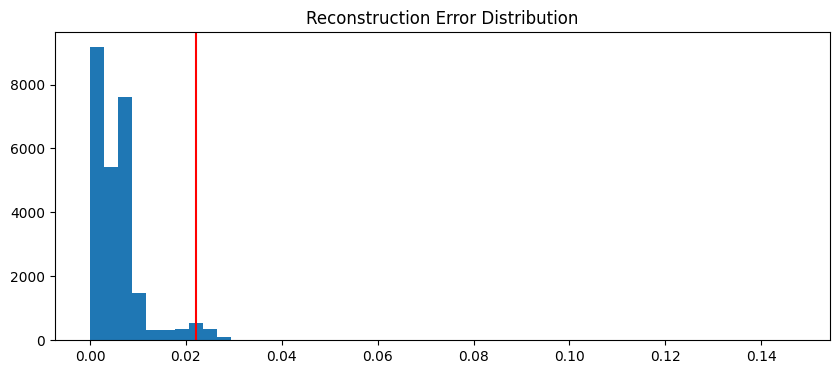

In [14]:
plt.figure(figsize=(10,4))
plt.hist(reconstruction_error, bins=50)
plt.axvline(threshold, color='red')
plt.title("Reconstruction Error Distribution")
plt.show()


In [15]:
model.save("lstm_ecg_autoencoder.keras")


In [16]:
from google.colab import files
files.download("lstm_ecg_autoencoder.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
normal_payload = {
    "type": "normal",
    "sampling_rate": sampling_rate,
    "window_size": WINDOW_SIZE,
    "ecg_windows": all_windows[:500].tolist()
}

with open("normal_ecg_windows.json", "w") as f:
    json.dump(normal_payload, f)

files.download("normal_ecg_windows.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
attack_windows = all_windows.copy()
attack_windows[:, 60:80] *= 2.5   # malicious spike

attack_payload = {
    "type": "data_injection",
    "sampling_rate": sampling_rate,
    "window_size": WINDOW_SIZE,
    "ecg_windows": attack_windows[:300].tolist()
}

with open("attack_ecg_windows.json", "w") as f:
    json.dump(attack_payload, f)

files.download("attack_ecg_windows.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# -----------------------------
# Create Ground Truth Labels
# -----------------------------
# 0 = normal ECG
# 1 = attack ECG

normal_errors = reconstruction_error
normal_labels = np.zeros(len(normal_errors))

# Simulated attack windows (already created in notebook)
attack_X = attack_windows.reshape((-1, WINDOW_SIZE, 1))

attack_pred = model.predict(attack_X)

attack_error = np.mean(
    np.square(attack_X - attack_pred),
    axis=(1,2)
)

attack_labels = np.ones(len(attack_error))

# -----------------------------
# Combine Normal + Attack Data
# -----------------------------

all_errors = np.concatenate([normal_errors, attack_error])
true_labels = np.concatenate([normal_labels, attack_labels])

# Predicted labels using threshold
pred_labels = (all_errors > threshold).astype(int)

# -----------------------------
# Evaluation Metrics
# -----------------------------

accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels)
recall = recall_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(true_labels, pred_labels))

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, pred_labels))

803/803 ━━━━━━━━━━━━━━━━━━━━ 64s 80ms/step
Accuracy: 0.7347502822219627
Precision: 0.9441048678105899
Recall: 0.4990462844018841
F1 Score: 0.6529489660792502

Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.97      0.79     25689
         1.0       0.94      0.50      0.65     25689

    accuracy                           0.73     51378
   macro avg       0.80      0.73      0.72     51378
weighted avg       0.80      0.73      0.72     51378


Confusion Matrix:
[[24930   759]
 [12869 12820]]


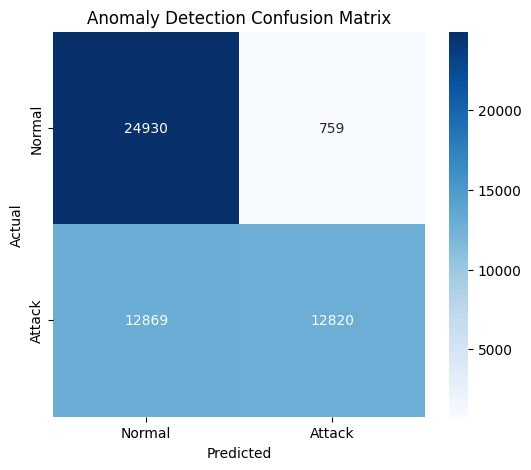

In [20]:
import seaborn as sns

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Attack"],
            yticklabels=["Normal","Attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Anomaly Detection Confusion Matrix")
plt.show()